In [4]:
library(ggplot2)
library(ggpubr)
library(naniar)
library(RColorBrewer)
library(car)

In [5]:
df <- read.csv('data/Data_Cortex_Nuclear.csv')
proteinas <- colnames(df[, 2:78])
df <- df[, c('MouseID', 'Genotype', 'Treatment', 'Behavior', 'class', proteinas)]
df$Genotype <- ifelse(df$Genotype == 'Control', 'c', 't')
df$Treatment <- ifelse(df$Treatment == 'Memantine', 'm', 's')
df$Behavior <- as.factor(gsub('/', '', df$Behavior))
df$class <- paste0(df$Genotype, df$Behavior, df$Treatment)
df$Genotype <- as.factor(df$Genotype)
df$Treatment <- as.factor(df$Treatment)
df$Behavior <- as.factor(df$Behavior)
df$class <- as.factor(df$class)

In [6]:
### Eliminar columnas con muchos NA values
df <- df[, !colnames(df) %in% c('BAD_N', 'BCL2_N', 'pCFOS_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N')]
### eliminar muestras con muchos NA values
df <- df[complete.cases(df), ]

Warning message:
“`gather_()` was deprecated in tidyr 1.2.0.
Please use `gather()` instead.”


,MouseID,Genotype,Treatment,Behavior,class,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,⋯,P3525_N,pCASP9_N,PSD95_N,SNCA_N,Ubiquitin_N,pGSK3B_Tyr216_N,SHH_N,pS6_N,SYP_N,CaNA_N
,<chr>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,309_1,c,m,CS,cCSm,0.5036439,0.7471932,0.4301753,2.816329,5.990152,⋯,0.2475378,1.603310,2.014875,0.1082343,1.0449792,0.8315565,0.1888517,0.1063052,0.4270992,1.675652
2,309_2,c,m,CS,cCSm,0.5146171,0.6890635,0.4117703,2.789514,5.685038,⋯,0.2576322,1.671738,2.004605,0.1097485,1.0098831,0.8492704,0.2004036,0.1065922,0.4415813,1.743610
3,309_3,c,m,CS,cCSm,0.5091831,0.7302468,0.4183088,2.687201,5.622059,⋯,0.2553430,1.663550,2.016831,0.1081962,0.9968476,0.8467087,0.1936845,0.1083031,0.4357769,1.926427
4,309_4,c,m,CS,cCSm,0.4421067,0.6170762,0.3586263,2.466947,4.979503,⋯,0.2511031,1.484624,1.957233,0.1198832,0.9902247,0.8332768,0.1921119,0.1031838,0.3916910,1.700563
5,309_5,c,m,CS,cCSm,0.4349402,0.6174298,0.3588022,2.365785,4.718679,⋯,0.2517730,1.534835,2.009109,0.1195244,0.9977750,0.8786678,0.2056042,0.1047838,0.4341538,1.839730
6,309_6,c,m,CS,cCSm,0.4475064,0.6281758,0.3673881,2.385939,4.807635,⋯,0.2444853,1.507777,2.003535,0.1206872,0.9201782,0.8436793,0.1904695,0.1064762,0.4398331,1.816389


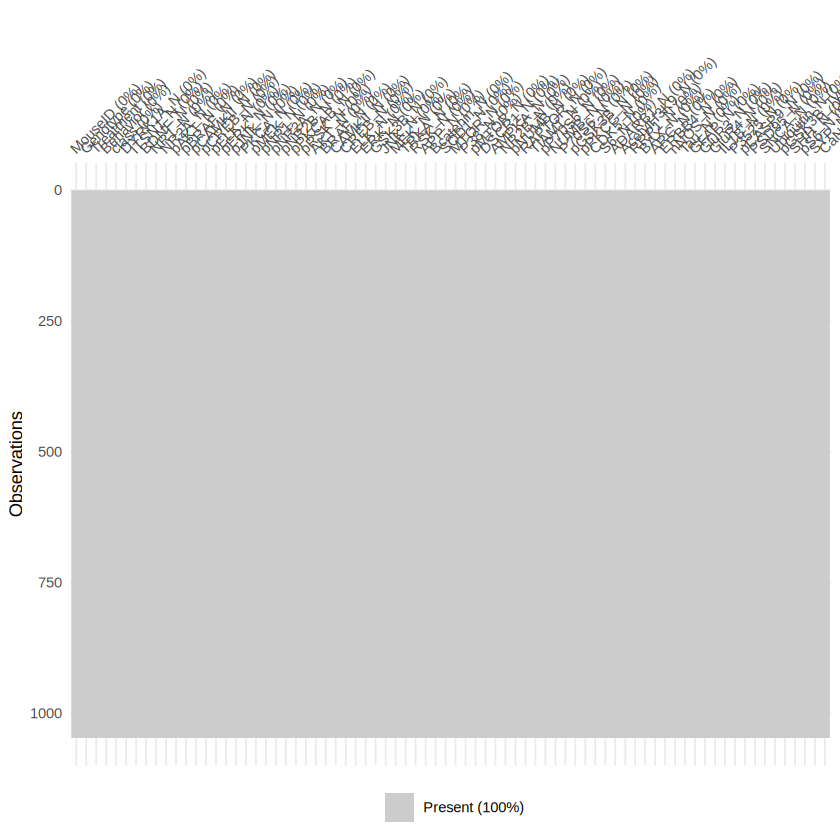

In [7]:
vis_miss(df)
head(df)

## Analisis exploratorio de datos

In [8]:
proteinas <- colnames(df[, 6:76])
Genotype_color <- c('#FB5607', '#FFBE0B')
Treatment_color <- c('#FB5607', '#FFBE0B')
Behavior_color <- c('#FB5607', '#FFBE0B')
class_color <- brewer.pal(8,'RdYlBu')

In [9]:
createViolinPlot <- function(variable, clase){
    colores <- get(paste0(clase, '_color'))
    p1 <- ggplot(df, aes_string(x = clase, y = variable, fill = clase)) + 
            geom_violin() +
            scale_fill_manual(values = colores) +
            theme_bw() +
            theme(axis.title.x = element_blank()) +
            coord_flip()
    p1
}

In [10]:
createDensityPlot <- function(variable, clase){
    colores <- get(paste0(clase, '_color'))
    p1 <- ggplot(df, aes_string(x = variable)) + 
            geom_density(aes_string(colour = clase)) +
            scale_color_manual(values = colores) +
            theme_bw()
    p1
}

In [11]:
createFig <- function(variable, clase){
    ggarrange(createViolinPlot(variable, clase), 
              createDensityPlot(variable, clase), 
              nrow = 2, ncol = 1, common.legend  = TRUE, legend = 'top', align = 'hv')
}

In [12]:
# options(repr.plot.width = 7, repr.plot.height = 7)

for (proteina in proteinas){
    createFig(proteina, 'class')
    ggsave(paste0('fig/eda/', proteina, '.pdf'))
    dev.off()
}



Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 6.67 in image

Saving 6.67 x 

In [13]:
### Coefientes de variacion por clase
aggregate(df[, 6:76], by = list(df$class), FUN = function(valor) { cv = sd(valor) *  100 / mean(valor)})

Group.1,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,⋯,P3525_N,pCASP9_N,PSD95_N,SNCA_N,Ubiquitin_N,pGSK3B_Tyr216_N,SHH_N,pS6_N,SYP_N,CaNA_N
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cCSm,26.99980,23.58478,13.82100,13.47633,22.59641,10.84470,10.60037,31.77183,13.83942,⋯,12.360211,16.722001,13.040608,13.897583,11.992888,11.531146,11.402805,14.146297,13.29225,13.19706
cCSs,91.13809,67.17443,16.90408,16.00501,24.36115,21.97021,16.57658,25.04588,19.05885,⋯,12.004418,22.698381,10.327401,11.025342,10.498985,16.956599,8.005600,8.990242,18.32463,17.03140
cSCm,17.54110,15.80848,13.26267,13.34482,19.36881,15.41752,16.31653,17.89189,16.08874,⋯,8.308588,15.775589,9.142463,13.242784,9.212582,7.247272,14.570061,4.937052,11.06059,13.45965
cSCs,17.55983,16.58435,13.57730,15.33663,23.09877,13.74575,12.82864,18.11758,14.14835,⋯,6.759048,9.639583,7.346614,11.006954,7.187034,9.019964,13.316608,5.340422,13.30157,15.03586
tCSm,25.29274,23.51413,16.36396,17.29263,24.58053,13.02407,11.97482,48.23997,12.12889,⋯,7.391973,14.621935,10.028109,14.333946,9.908774,8.027519,9.918688,7.500779,15.52325,12.99029
tCSs,26.61994,20.30352,14.19159,12.63188,18.11968,16.75444,11.37497,30.35172,13.41800,⋯,11.482720,16.154670,10.556674,13.441111,10.582484,11.591589,11.342730,9.394082,18.63459,15.29351
tSCm,23.83486,13.74117,10.34562,10.85849,20.65464,14.46171,11.96312,23.81690,12.16717,⋯,8.342926,11.382619,11.673971,11.783870,9.326742,10.516911,15.520495,7.440459,10.86274,15.19440
tSCs,22.08641,20.30134,17.67397,16.98894,28.36433,18.32398,12.46966,36.67754,15.06123,⋯,7.723300,14.216692,9.547726,9.801118,9.986545,9.921432,11.487159,8.531757,15.54878,15.26077


In [14]:
df_norm <- data.frame()
for(proteina in proteinas){
    datos_cCSm <- df[df$class == 'cCSm', c(proteina)]
    datos_cCSs <- df[df$class == 'cCSs', c(proteina)]
    datos_cSCm <- df[df$class == 'cSCm', c(proteina)]
    datos_cSCs <- df[df$class == 'cSCs', c(proteina)]
    datos_tCSm <- df[df$class == 'tCSm', c(proteina)]
    datos_tCSs <- df[df$class == 'tCSs', c(proteina)]
    datos_tSCm <- df[df$class == 'tSCm', c(proteina)]
    datos_tSCs <- df[df$class == 'tSCs', c(proteina)]
    
    cCSm = shapiro.test(datos_cCSm)
    cCSs = shapiro.test(datos_cCSs)
    cSCm = shapiro.test(datos_cSCm)
    cSCs = shapiro.test(datos_cSCs)
    tCSm = shapiro.test(datos_tCSm)
    tCSs = shapiro.test(datos_tCSs)
    tSCm = shapiro.test(datos_tSCm)
    tSCs = shapiro.test(datos_tSCs)
    
    
    df_norm2 <- data.frame(proteina = proteina,
                            cCSm = cCSm$p.value,
                            cCSs = cCSs$p.value,
                            cSCm = cSCm$p.value,
                            cSCs = cSCs$p.value,
                            tCSm = tCSm$p.value,
                            tCSs = tCSs$p.value,
                            tSCm = tSCm$p.value,
                            tSCs = tSCs$p.value)
    df_norm <- rbind(df_norm, df_norm2)
}
head(df_norm)

,proteina,cCSm,cCSs,cSCm,cSCs,tCSm,tCSs,tSCm,tSCs
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,DYRK1A_N,0.001238472,2.807138e-17,0.2063222118,0.32446244,0.001254678,8.609983e-08,1.489641e-13,1.355429e-01
2,ITSN1_N,0.003367686,3.367657e-16,0.9921869385,0.28199496,0.023757671,1.728458e-03,7.502940e-01,2.241483e-01
3,BDNF_N,0.110753581,4.368420e-01,0.0007044136,0.03993194,0.015438504,1.394412e-05,4.634791e-03,1.840015e-01
4,NR1_N,0.012466745,6.407346e-03,0.0665591109,0.22500400,0.071409291,2.742436e-03,8.184713e-02,8.320616e-02
5,NR2A_N,0.007102195,3.894848e-04,0.0098779182,0.11114887,0.017562305,1.622686e-01,9.121160e-02,2.688183e-02
6,pAKT_N,0.092241647,5.434322e-02,0.0009281481,0.03991876,0.159562931,7.082414e-06,1.110984e-06,1.948695e-09


In [15]:
for(column in colnames(df_norm[, 2:9])){
    print(
        paste0(column, ' : ',
                round(nrow(df_norm[df_norm[, c(column)] >= 0.05, ]) * 100 / nrow(df_norm)),
                ' %')
    )
}

[1] "cCSm : 34 %"
[1] "cCSs : 31 %"
[1] "cSCm : 38 %"
[1] "cSCs : 41 %"
[1] "tCSm : 35 %"
[1] "tCSs : 23 %"
[1] "tSCm : 27 %"
[1] "tSCs : 37 %"


In [16]:
summary(df)

   MouseID          Genotype Treatment Behavior     class        DYRK1A_N     
 Length:1047        c:540    m:570     CS:510   cCSm   :150   Min.   :0.1453  
 Class :character   t:507    s:477     SC:537   cSCm   :150   1st Qu.:0.2894  
 Mode  :character                               tCSm   :135   Median :0.3664  
                                                tSCm   :135   Mean   :0.4277  
                                                tSCs   :132   3rd Qu.:0.4888  
                                                cCSs   :120   Max.   :2.5164  
                                                (Other):225                   
    ITSN1_N           BDNF_N           NR1_N           NR2A_N     
 Min.   :0.2454   Min.   :0.1152   Min.   :1.331   Min.   :1.738  
 1st Qu.:0.4748   1st Qu.:0.2864   1st Qu.:2.052   1st Qu.:3.143  
 Median :0.5676   Median :0.3149   Median :2.292   Median :3.720  
 Mean   :0.6200   Mean   :0.3181   Mean   :2.295   Mean   :3.832  
 3rd Qu.:0.7020   3rd Qu.:0.3464 

In [17]:
save.image()